In [4]:
import pandas as pd
from sqlalchemy import create_engine

In [14]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASS')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}"
    f"/{os.getenv('POSTGRES_DB').strip()}"
)

In [15]:
with engine.connect() as conn:
    print("Connection successful!")

Connection successful!


In [19]:
faa_stats = pd.read_sql(
    """
    select *
    from s_nedalgubran.mart_faa_stats
    """,
    engine
)
faa_stats.head()

,airport_code,departure_connections,arrival_connections,total_flights,total_cancelled,total_diverted,actual_flights,unique_airplanes,unique_airlines,airport_name,city,country
0,ABE,12,12,521,35,4,486,97.0,3.0,Lehigh Valley International Airport,Allentown,United States
1,ABI,1,1,296,27,0,269,73.0,1.0,Abilene Regional Airport,Abilene,United States
2,ABQ,23,23,3514,81,1,3433,1080.0,7.0,Albuquerque International Sunport,Albuquerque,United States
3,ABR,1,1,122,4,0,118,15.0,1.0,Aberdeen Regional Airport,Aberdeen,United States
4,ACT,1,1,186,22,0,164,68.0,2.0,Waco Regional Airport,Waco,United States


In [20]:
import pandas as pd

In [24]:
faa_stats.columns

Index(['airport_code', 'departure_connections', 'arrival_connections',
       'total_flights', 'total_cancelled', 'total_diverted', 'actual_flights',
       'unique_airplanes', 'unique_airlines', 'airport_name', 'city',
       'country'],
      dtype='str')

In [25]:
faa_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   airport_code           342 non-null    str    
 1   departure_connections  342 non-null    int64  
 2   arrival_connections    342 non-null    int64  
 3   total_flights          342 non-null    int64  
 4   total_cancelled        342 non-null    int64  
 5   total_diverted         342 non-null    int64  
 6   actual_flights         342 non-null    int64  
 7   unique_airplanes       341 non-null    float64
 8   unique_airlines        341 non-null    float64
 9   airport_name           341 non-null    str    
 10  city                   341 non-null    str    
 11  country                341 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 32.2 KB


In [23]:
faa_stats.shape

(342, 12)

In [26]:
top_airports = (
    faa_stats
    .sort_values(
        "total_flights",
        ascending=False
    )
    .head(10)
)

top_airports[
    [
        "airport_code",
        "airport_name",
        "total_flights"
    ]
]

,airport_code,airport_name,total_flights
234,ORD,Chicago O'Hare International Airport,50250
17,ATL,Hartsfield Jackson Atlanta International Airport,49185
87,DEN,Denver International Airport,48969
88,DFW,Dallas Fort Worth International Airport,48458
245,PHX,Phoenix Sky Harbor International Airport,33129
180,LAX,Los Angeles International Airport,29626
68,CLT,Charlotte Douglas International Airport,28450
200,MCO,Orlando International Airport,27581
178,LAS,McCarran International Airport,27404
291,SEA,Seattle Tacoma International Airport,23860


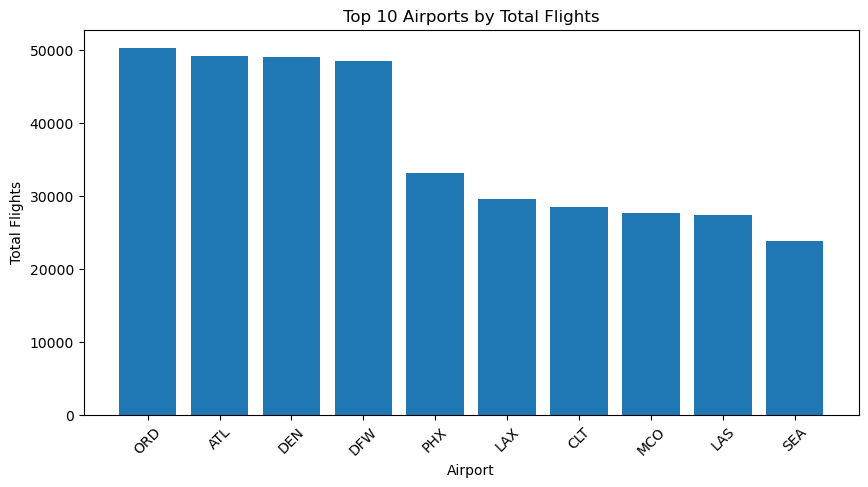

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top_airports["airport_code"],
    top_airports["total_flights"]
)

plt.xlabel("Airport")
plt.ylabel("Total Flights")
plt.title("Top 10 Airports by Total Flights")

plt.xticks(rotation=45)

plt.show()

In [ ]:
## Flight Analysis: Total Flights by Airport

'''Here we calculate the total number of flights for each airport and 
identify the busiest airports.'''

In [28]:
# Load flight route statistics from the data mart

route_stats = pd.read_sql(
    """
    SELECT *
    FROM s_nedalgubran.mart_route_stats
    """,
    engine
)

route_stats.head()

,origin,dest,total_flights,unique_airplanes,unique_airlines,avg_actual_elapsed_time,avg_arrival_delay,max_delay,min_delay,total_cancelled,total_diverted,origin_name,origin_city,origin_country,destination_name,destination_city,destination_country
0,SRQ,ABE,9,6,1,149.375000,12.875000,160.0,-43.0,1,0,Sarasota Bradenton International Airport,Sarasota,United States,Lehigh Valley International Airport,Allentown,United States
1,RSW,ABE,8,4,1,162.571429,52.142857,320.0,-24.0,1,0,Southwest Florida International Airport,Fort Myers,United States,Lehigh Valley International Airport,Allentown,United States
2,SFB,ABE,50,18,1,140.340426,26.957447,718.0,-34.0,2,1,Orlando Sanford International Airport,Sanford,United States,Lehigh Valley International Airport,Allentown,United States
3,ORD,ABE,53,22,1,129.720000,34.240000,313.0,-41.0,3,0,Chicago O'Hare International Airport,Chicago,United States,Lehigh Valley International Airport,Allentown,United States
4,MCO,ABE,8,5,1,150.571429,41.714286,239.0,-30.0,1,0,Orlando International Airport,Orlando,United States,Lehigh Valley International Airport,Allentown,United States


## Route Analysis: Most Frequent Flight Routes

Here we calculate the number of flights for each route and identify the most frequently used connections.

In [31]:
route_stats.columns

Index(['origin', 'dest', 'total_flights', 'unique_airplanes',
       'unique_airlines', 'avg_actual_elapsed_time', 'avg_arrival_delay',
       'max_delay', 'min_delay', 'total_cancelled', 'total_diverted',
       'origin_name', 'origin_city', 'origin_country', 'destination_name',
       'destination_city', 'destination_country'],
      dtype='str')

In [32]:
top_routes = (
    route_stats
    .sort_values(
        "total_flights",
        ascending=False
    )
    .head(10)
)

top_routes[
    [
        "origin",
        "dest",
        "total_flights"
    ]
]

,origin,dest,total_flights
3066,ORD,LGA,955
4057,LGA,ORD,951
2307,OGG,HNL,898
3815,HNL,OGG,897
2747,LAX,JFK,825
2944,JFK,LAX,825
2932,SFO,LAX,774
5122,LAX,SFO,772
666,DCA,BOS,754
1323,BOS,DCA,754


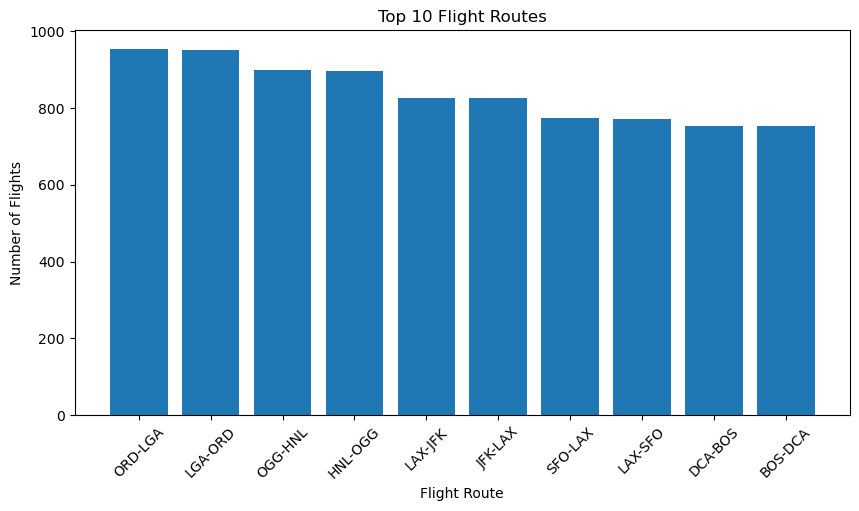

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top_routes["origin"] + "-" + top_routes["dest"],
    top_routes["total_flights"]
)

plt.xlabel("Flight Route")
plt.ylabel("Number of Flights")
plt.title("Top 10 Flight Routes")

plt.xticks(rotation=45)

plt.show()

## Flight Delay Analysis

Here we analyze the routes with the highest average arrival delay.

In [34]:
delay_routes = (
    route_stats
    .sort_values(
        "avg_arrival_delay",
        ascending=False
    )
    .head(10)
)

delay_routes[
    [
        "origin",
        "dest",
        "avg_arrival_delay"
    ]
]

,origin,dest,avg_arrival_delay
526,SYR,BNA,1086.000000
45,PHL,ACY,810.000000
5582,ORD,STX,335.600000
3981,STX,ORD,329.000000
3273,DSM,MCO,274.000000
1733,MCO,DSM,223.000000
718,LAX,BUF,216.600000
4940,PHX,SCK,211.222222
3966,GUC,ORD,205.500000
2088,FSD,FLL,157.777778


## Flight Delay Analysis

Here we analyze which routes have the highest average arrival delays.

In [35]:
delay_routes = (
    route_stats
    .sort_values(
        "avg_arrival_delay",
        ascending=False
    )
    .head(10)
)

delay_routes[
    [
        "origin",
        "dest",
        "avg_arrival_delay",
        "max_delay",
        "min_delay"
    ]
]

,origin,dest,avg_arrival_delay,max_delay,min_delay
526,SYR,BNA,1086.000000,1086.0,1086.0
45,PHL,ACY,810.000000,810.0,810.0
5582,ORD,STX,335.600000,1577.0,-17.0
3981,STX,ORD,329.000000,1629.0,-44.0
3273,DSM,MCO,274.000000,274.0,274.0
1733,MCO,DSM,223.000000,223.0,223.0
718,LAX,BUF,216.600000,617.0,6.0
4940,PHX,SCK,211.222222,934.0,-22.0
3966,GUC,ORD,205.500000,403.0,8.0
2088,FSD,FLL,157.777778,1266.0,-24.0


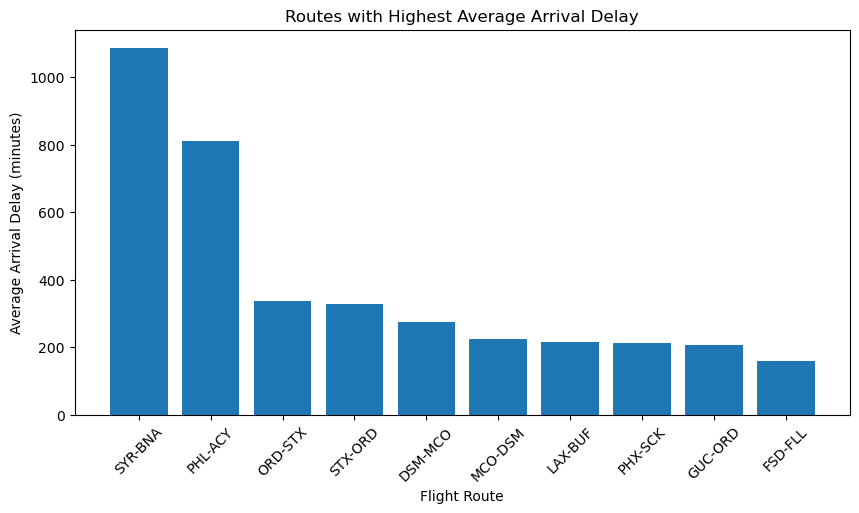

In [36]:
plt.figure(figsize=(10,5))

plt.bar(
    delay_routes["origin"] + "-" + delay_routes["dest"],
    delay_routes["avg_arrival_delay"]
)

plt.xlabel("Flight Route")
plt.ylabel("Average Arrival Delay (minutes)")
plt.title("Routes with Highest Average Arrival Delay")

plt.xticks(rotation=45)

plt.show()

## Weather Impact Analysis

Here we analyze the relationship between weather conditions and flight operations.

In [37]:
weather_flights = pd.read_sql(
    """
    SELECT *
    FROM s_nedalgubran.mart_selected_faa_stats_weather
    """,
    engine
)

weather_flights.head()

,airport_code,flight_date,departure_connections,total_flights,total_cancelled,total_diverted,actual_flights,unique_airplanes,unique_airlines,airport_name,city,country,min_temp_c,max_temp_c,precipitation_mm,max_snow_mm,avg_wind_direction,avg_wind_speed_kmh,wind_peakgust_kmh
0,ABE,2026-01-01,4,7,0,0,7,6,2,Lehigh Valley International Airport,Allentown,United States,NaN,NaN,NaN,NaN,None,NaN,None
1,ABE,2026-01-02,8,12,0,0,12,9,3,Lehigh Valley International Airport,Allentown,United States,NaN,NaN,NaN,NaN,None,NaN,None
2,ABE,2026-01-03,8,12,0,0,12,9,2,Lehigh Valley International Airport,Allentown,United States,NaN,NaN,NaN,NaN,None,NaN,None
3,ABE,2026-01-04,6,11,0,1,11,8,2,Lehigh Valley International Airport,Allentown,United States,NaN,NaN,NaN,NaN,None,NaN,None
4,ABE,2026-01-05,6,8,0,0,8,6,2,Lehigh Valley International Airport,Allentown,United States,NaN,NaN,NaN,NaN,None,NaN,None


In [38]:
weather_flights.columns

Index(['airport_code', 'flight_date', 'departure_connections', 'total_flights',
       'total_cancelled', 'total_diverted', 'actual_flights',
       'unique_airplanes', 'unique_airlines', 'airport_name', 'city',
       'country', 'min_temp_c', 'max_temp_c', 'precipitation_mm',
       'max_snow_mm', 'avg_wind_direction', 'avg_wind_speed_kmh',
       'wind_peakgust_kmh'],
      dtype='str')

## Weather Impact: Precipitation and Flight Cancellations

Here we analyze whether precipitation is related to the number of cancelled flights.

In [39]:
weather_flights[
    [
        "precipitation_mm",
        "total_cancelled"
    ]
].corr()

,precipitation_mm,total_cancelled
precipitation_mm,1.000000,0.301494
total_cancelled,0.301494,1.000000


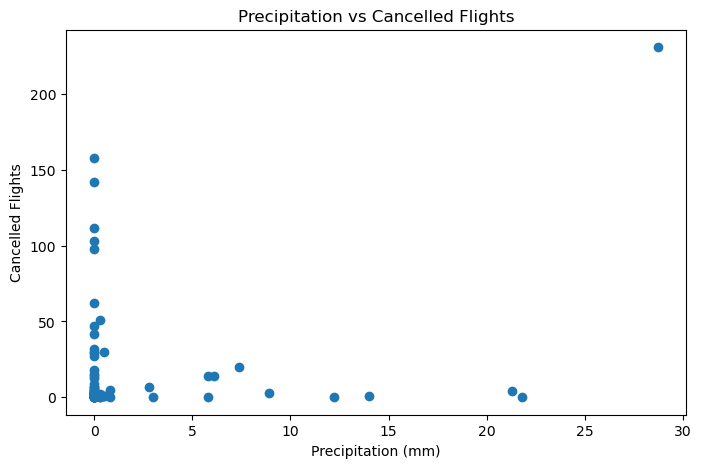

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(
    weather_flights["precipitation_mm"],
    weather_flights["total_cancelled"]
)

plt.xlabel("Precipitation (mm)")
plt.ylabel("Cancelled Flights")
plt.title("Precipitation vs Cancelled Flights")

plt.show()

## Weather Impact: Wind Speed and Cancellations

Here we analyze whether stronger winds are associated with more cancelled flights.

In [41]:
weather_flights[
    [
        "avg_wind_speed_kmh",
        "total_cancelled"
    ]
].corr()

,avg_wind_speed_kmh,total_cancelled
avg_wind_speed_kmh,1.000000,0.191886
total_cancelled,0.191886,1.000000


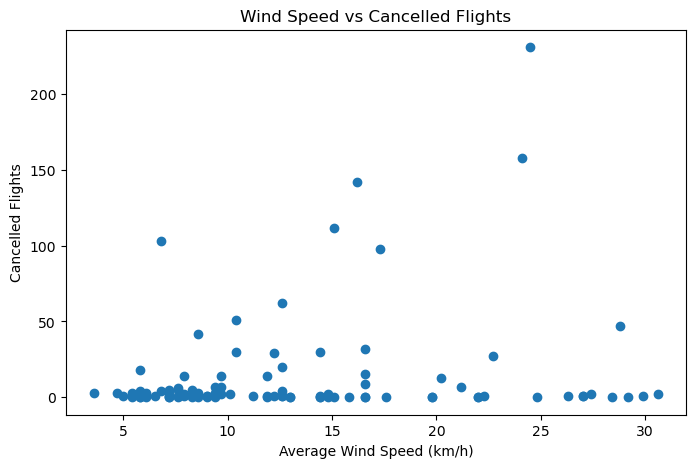

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(
    weather_flights["avg_wind_speed_kmh"],
    weather_flights["total_cancelled"]
)

plt.xlabel("Average Wind Speed (km/h)")
plt.ylabel("Cancelled Flights")
plt.title("Wind Speed vs Cancelled Flights")

plt.show()

In [43]:
worst_weather_days = (
    weather_flights
    .sort_values(
        "total_cancelled",
        ascending=False
    )
    .head(10)
)

worst_weather_days[
    [
        "airport_code",
        "flight_date",
        "total_cancelled",
        "precipitation_mm",
        "avg_wind_speed_kmh"
    ]
]

,airport_code,flight_date,total_cancelled,precipitation_mm,avg_wind_speed_kmh
2671,DFW,2026-01-24,679,NaN,NaN
2672,DFW,2026-01-25,626,NaN,NaN
2673,DFW,2026-01-26,540,NaN,NaN
528,ATL,2026-01-25,517,NaN,NaN
2052,CLT,2026-01-25,422,NaN,NaN
2548,DCA,2026-01-25,397,NaN,NaN
2058,CLT,2026-01-31,391,NaN,NaN
5705,LGA,2026-01-25,330,NaN,NaN
2549,DCA,2026-01-26,321,NaN,NaN
3226,EWR,2026-01-25,308,NaN,NaN


## Weekly Weather Analysis

Here we analyze weather patterns aggregated by week.

In [44]:
weather_weekly = pd.read_sql(
    """
    SELECT *
    FROM s_nedalgubran.mart_weather_weekly
    """,
    engine
)

weather_weekly.head()

,airport_code,station_id,week,avg_temp,min_temp,max_temp,total_precipitation,total_snow,avg_wind_direction,avg_wind_speed,peak_gust,season
0,MIA,72202,2025-12-29,17.000000,7.8,26.7,0.0,0.0,None,6.125000,None,winter
1,MIA,72202,2026-03-23,23.642857,16.1,29.4,15.7,0.0,None,11.471429,None,spring
2,LAX,72295,2026-03-16,20.042857,14.0,32.0,NaN,NaN,None,10.128571,None,spring
3,LAX,72295,2026-03-02,17.985714,11.0,31.0,NaN,NaN,None,12.828571,None,spring
4,JFK,74486,2026-03-16,5.357143,-3.9,14.4,16.1,0.0,None,22.171429,None,spring


In [45]:
weather_weekly.columns

Index(['airport_code', 'station_id', 'week', 'avg_temp', 'min_temp',
       'max_temp', 'total_precipitation', 'total_snow', 'avg_wind_direction',
       'avg_wind_speed', 'peak_gust', 'season'],
      dtype='str')

## Weekly Weather Overview

Here we analyze weekly weather patterns, including temperature, precipitation and wind conditions.

In [46]:
weather_weekly.head()

,airport_code,station_id,week,avg_temp,min_temp,max_temp,total_precipitation,total_snow,avg_wind_direction,avg_wind_speed,peak_gust,season
0,MIA,72202,2025-12-29,17.000000,7.8,26.7,0.0,0.0,None,6.125000,None,winter
1,MIA,72202,2026-03-23,23.642857,16.1,29.4,15.7,0.0,None,11.471429,None,spring
2,LAX,72295,2026-03-16,20.042857,14.0,32.0,NaN,NaN,None,10.128571,None,spring
3,LAX,72295,2026-03-02,17.985714,11.0,31.0,NaN,NaN,None,12.828571,None,spring
4,JFK,74486,2026-03-16,5.357143,-3.9,14.4,16.1,0.0,None,22.171429,None,spring


## Wettest Weeks

Here we identify the weeks with the highest precipitation.

In [47]:
wettest_weeks = (
    weather_weekly
    .sort_values(
        "total_precipitation",
        ascending=False
    )
    .head(10)
)

wettest_weeks[
    [
        "airport_code",
        "week",
        "total_precipitation",
        "season"
    ]
]

,airport_code,week,total_precipitation,season
40,LAX,2026-02-16,70.9,winter
32,JFK,2026-03-02,52.1,spring
33,LAX,2025-12-29,36.0,winter
5,MIA,2026-01-12,35.4,winter
26,JFK,2026-02-23,32.0,winter
12,JFK,2026-02-16,31.2,winter
16,MIA,2026-03-09,29.0,spring
11,MIA,2026-03-30,28.9,spring
23,JFK,2026-01-19,28.7,winter
10,JFK,2026-01-05,23.2,winter


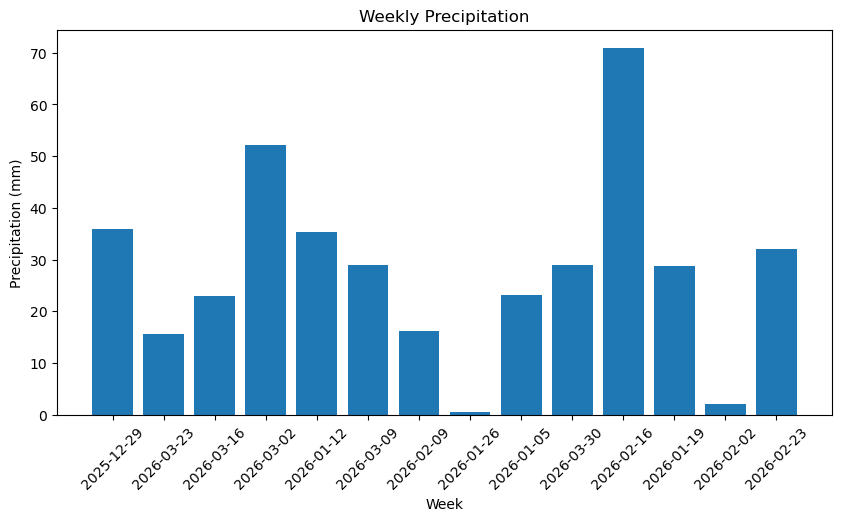

In [48]:
plt.figure(figsize=(10,5))

plt.bar(
    weather_weekly["week"].astype(str),
    weather_weekly["total_precipitation"]
)

plt.xlabel("Week")
plt.ylabel("Precipitation (mm)")
plt.title("Weekly Precipitation")

plt.xticks(rotation=45)

plt.show()

In [49]:
#average temp every seasen
season_temp = (
    weather_weekly
    .groupby("season")["avg_temp"]
    .mean()
)

season_temp

season
spring    16.240952
winter    11.442063
Name: avg_temp, dtype: float64

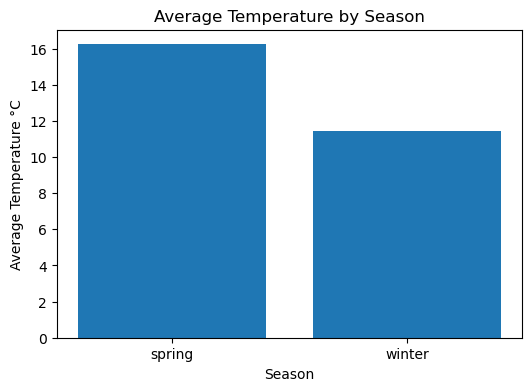

In [50]:
plt.figure(figsize=(6,4))

plt.bar(
    season_temp.index,
    season_temp.values
)

plt.xlabel("Season")
plt.ylabel("Average Temperature °C")
plt.title("Average Temperature by Season")

plt.show()

## Project Insights Summary

This section summarizes the main findings from the flight and weather analysis.

In [55]:
#  airports represent the highest operational activity
top_airports = (
    faa_stats 
    .sort_values(
        "total_flights",
        ascending=False
    )
    .head(10)
)

top_airports[
    [
        "airport_code",
        "airport_name",
        "city",
        "total_flights"
    ]
]

,airport_code,airport_name,city,total_flights
234,ORD,Chicago O'Hare International Airport,Chicago,50250
17,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,49185
87,DEN,Denver International Airport,Denver,48969
88,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,48458
245,PHX,Phoenix Sky Harbor International Airport,Phoenix,33129
180,LAX,Los Angeles International Airport,Los Angeles,29626
68,CLT,Charlotte Douglas International Airport,Charlotte,28450
200,MCO,Orlando International Airport,Orlando,27581
178,LAS,McCarran International Airport,Las Vegas,27404
291,SEA,Seattle Tacoma International Airport,Seattle,23860


### Insight

The busiest airports were identified based on the total number of flights.
These airports represent the highest operational activity in the dataset.

In [52]:
top_routes[
    [
        "origin",
        "dest",
        "total_flights"
    ]
]

,origin,dest,total_flights
3066,ORD,LGA,955
4057,LGA,ORD,951
2307,OGG,HNL,898
3815,HNL,OGG,897
2747,LAX,JFK,825
2944,JFK,LAX,825
2932,SFO,LAX,774
5122,LAX,SFO,772
666,DCA,BOS,754
1323,BOS,DCA,754


#The analysis identified the most frequently used flight connections.
These routes represent the highest passenger and operational demand.

In [ ]:
#  higher average arrival delays
delay_routes[
    [
        "origin",
        "dest",
        "avg_arrival_delay"
    ]
]

,origin,dest,avg_arrival_delay
526,SYR,BNA,1086.000000
45,PHL,ACY,810.000000
5582,ORD,STX,335.600000
3981,STX,ORD,329.000000
3273,DSM,MCO,274.000000
1733,MCO,DSM,223.000000
718,LAX,BUF,216.600000
4940,PHX,SCK,211.222222
3966,GUC,ORD,205.500000
2088,FSD,FLL,157.777778


### Insight

Some routes show higher average arrival delays compared to others.
Possible reasons include traffic, distance, airport congestion, or weather conditions.

### Insight

A positive correlation was found between precipitation and cancelled flights
(correlation = 0.30). This suggests that rainy conditions may contribute to
flight cancellations, although other factors also affect cancellations.

### Insight

The available weather data contains winter and spring observations.
Spring had a higher average temperature compared to winter.
A full seasonal comparison would require a complete year of data.